### Wine Quality Test Prediction

In [1]:
# Load and preprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv('../../data/wine-qt.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


- Data preprocessing

In [5]:
print("Missing values:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Duplicates: 0


In [6]:
X = df.drop("quality", axis=1)
y = df["quality"]

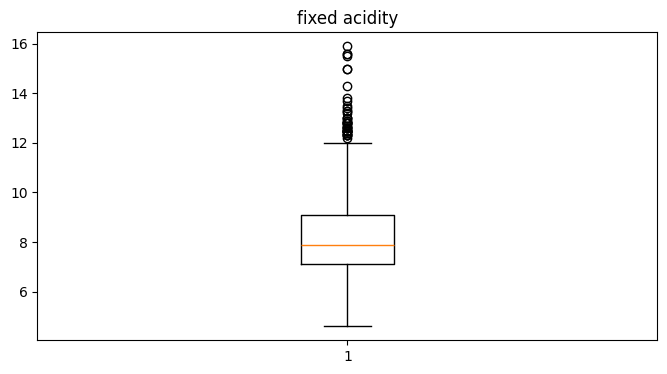

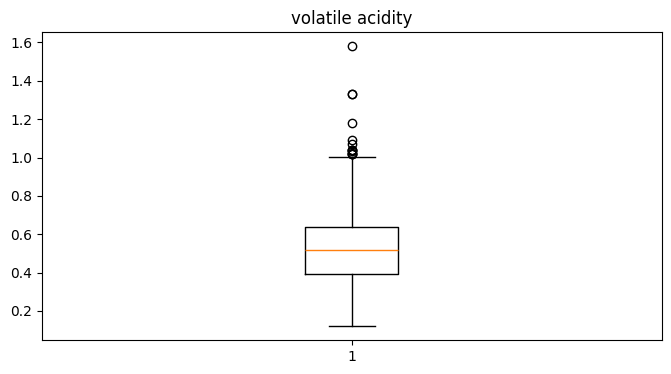

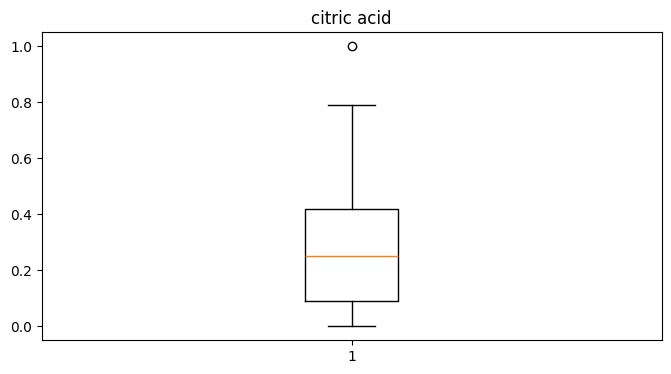

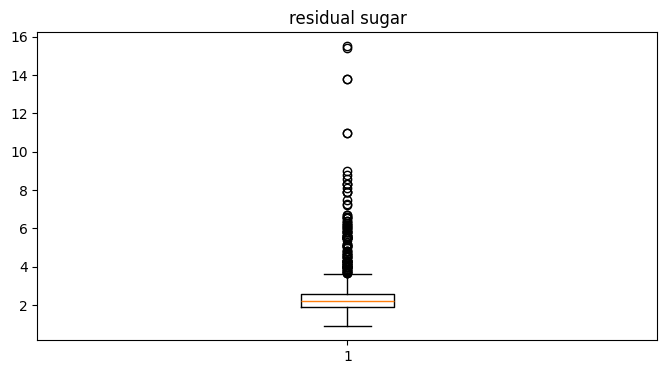

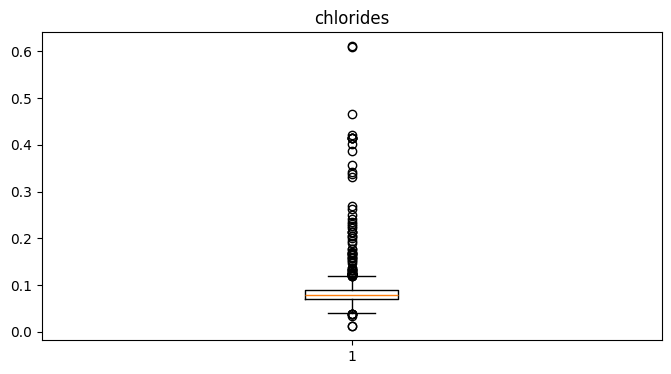

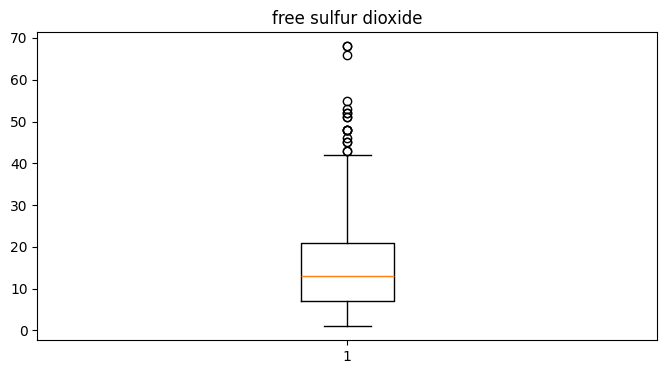

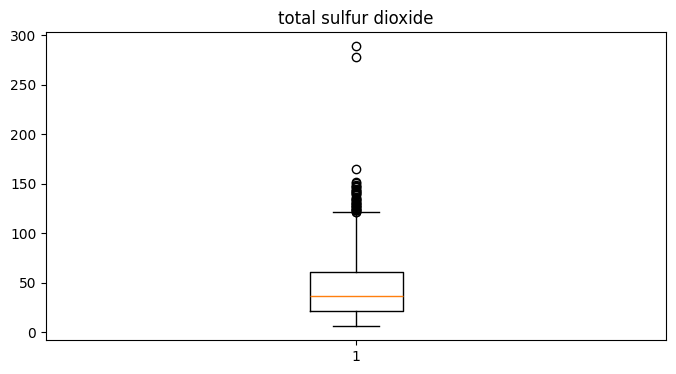

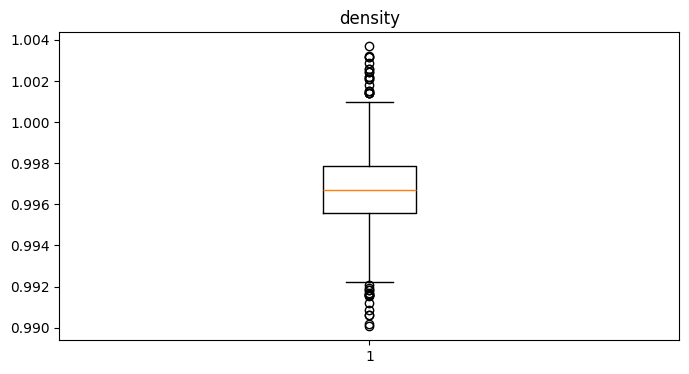

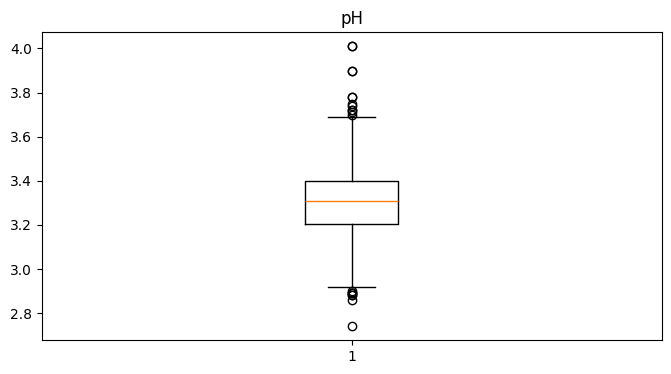

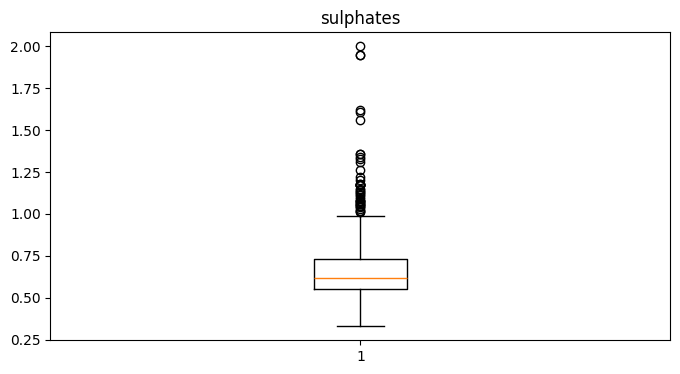

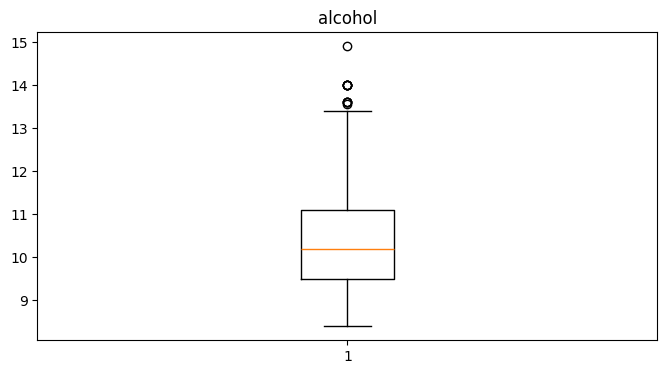

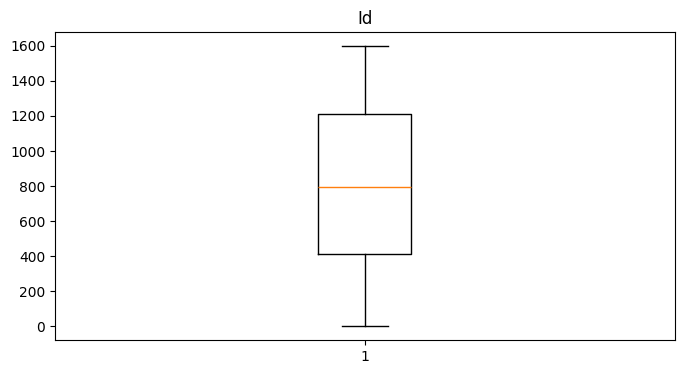

In [7]:
for col in X.columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [8]:
for col in X.columns:
    
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    X[col] = X[col].clip(lower=lower, upper=upper)

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

- Splitting and Training

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski'
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion='entropy',
        max_depth=10,
        random_state=42
    ),

    "SVM": SVC(
        kernel='linear',
        C=1.0,
        gamma='scale'
    )
}

- Evaluation and Visualization

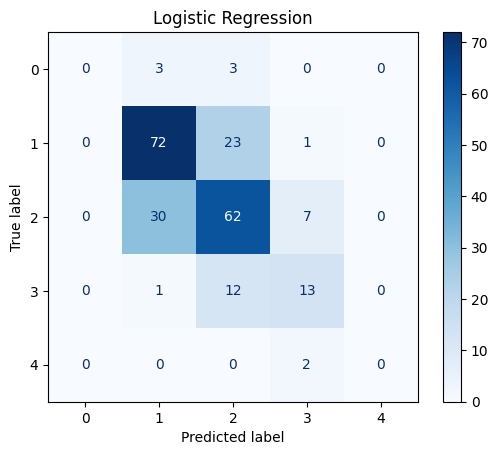

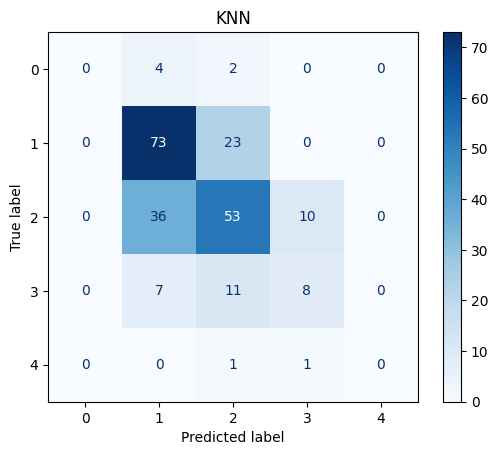

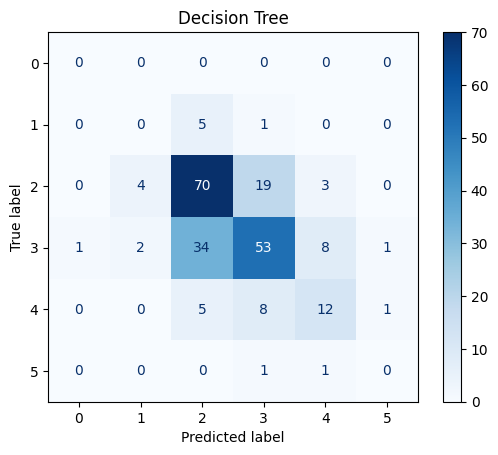

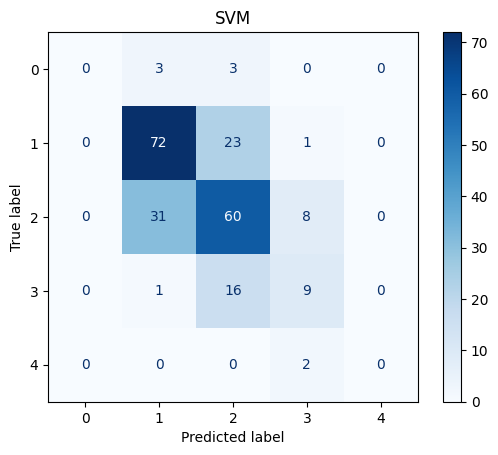

In [12]:
results = []

best_model = None
best_score = 0
best_model_name = ""

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    
    pre = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=1
    )
    
    rec = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=1
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=1
    )
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1
    })
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    
    plt.title(name)
    plt.show()
    
    # Track best model
    if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name

In [13]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.641921   0.772893  0.375253  0.373320
1                  KNN  0.585153   0.723655  0.320693  0.318466
2        Decision Tree  0.589520   0.293396  0.454343  0.288717
3                  SVM  0.615721   0.742226  0.340443  0.339536


In [14]:
joblib.dump(best_model, "../../models/wine_model.pkl")

print("Best Model:", best_model_name)
print("Best Accuracy:", best_score)

Best Model: Logistic Regression
Best Accuracy: 0.6419213973799127
